# Benchmark water clusters: binding energies and relaxed geometries

Where the rsfff models land on the standard set of water-cluster minima, next to the numbers
published for MB-Pol and CMM. The clusters are the 25 in `data/kristina_clusters/all_clusters.xyz`
-- dimer through `(H2O)25`, several isomers each at n = 6, 8, 16 and 20.

Everything here reads one file, `data/kristina_clusters/benchmark_clusters.csv`, which
`scripts/build_benchmark_clusters_csv.py` builds by joining two sources row by row:

- the **published table**, transcribed by hand: q-AQUA, MB-Pol, CMM, wB97X-V and HIPPO binding
  energies, the reference binding energies, and the RMSD of each method's relaxed geometry to
  the reference minimum;
- the **rsfff models**, straight out of `scripts/optimize_clusters.py` run on member 0 of the
  two ~100k-parameter film committees, fitted on the same data with the same architecture and
  differing only in how intramolecular pairs are treated:
  `rsfff_active_learning/committees/film_committee_100k` (`rsfff 100k (range-sep.)`: every
  pair carries the classical channels behind a learned Fermi switch) and
  `rsfff_active_learning/committees/film_committee_100k_excl` (`rsfff 100k (exclusions)`: the
  1-2/1-3 pairs are removed and the monomer is Morse + angle alone -- strictly non-reactive).
  The CSV still carries the older `film` / `film_large` checkpoints for reference.

Two quantities, and they are the same two for every method, which is the only reason the
comparison is fair:

**binding energy** is `E_cluster - n * E_monomer` evaluated at *that method's own relaxed
geometry*, so monomer deformation is inside it. Errors are quoted **per water**, because a
20-mer has ten times the hydrogen bonds of a dimer and an unnormalized MAE would be a plot of
cluster size.

**RMSD** is the all-atom Kabsch RMSD between the method's relaxed geometry and the reference
minimum -- shape, not placement. A method can get the energy right on a structure it has moved
off the reference minimum, so the two figures are not redundant.

**One caveat on the transcription.** The published tables carry their own footers, and most of
them reproduce exactly from the values in the CSV: q-AQUA MAE/n 0.040, CMM 0.100, HIPPO 0.194,
and mean RMSD 0.026 / 0.046 / 0.017 for q-AQUA / MB-Pol / wB97X-V. Those agreements are what
validate the reference column. Two do not reproduce -- MB-Pol MAE/n comes out 0.109 against a
published 0.156, and wB97X-V 0.057 against 0.051 -- so either a value in one of those two
columns was mis-read off the table or the published footer was computed over something slightly
different. The MB-Pol *column* is good enough to plot against; its *aggregate* is unverified.

In [1]:
%matplotlib inline

import csv
import os
from pathlib import Path

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import matplotlib.pyplot as plt
import numpy as np

# Resolve the repository root no matter where Jupyter starts the kernel.
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

BENCHMARK_CSV = ROOT / "data/kristina_clusters/benchmark_clusters.csv"
FIGDIR = ROOT / "notebooks/figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 220,
    "font.size": 9,
    "axes.edgecolor": "#b9bfcb",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#e6e9f0",
    "grid.linewidth": 0.7,
    "axes.axisbelow": True,
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.labelcolor": "#0b0b0b",
    "legend.frameon": False,
})

# The reference is not a series -- it is the axis everything else is measured against, so it
# gets ink rather than a hue. The four hues are a CVD-checked categorical set and each method
# also carries its own marker, so identity never rests on colour alone.
#: y range of the residual panel; points outside it are drawn as arrows at the edge with their
#: value (w20 Fused Cubes on the exclusion model, which collapsed to another structure).
ERR_YLIM = (-1.0, 0.6)
REFERENCE_INK = "#242934"
SURFACE = "#fcfcfb"
# The two rsfff series are the ~100k-parameter film committees, member 0 of each, fitted on the
# same data with the same architecture: `film_committee_100k` (range-separated intramolecular
# pairs) and `film_committee_100k_excl` (hard 1-2/1-3 exclusions, strictly non-reactive). The
# CSV also still carries the older `film` / `film_large` checkpoints; add them back here to plot.
METHODS = [
    ("mbpol",          "MB-Pol",                   "#2a78d6", "o"),
    ("cmm",            "CMM",                      "#eb6834", "s"),
    ("film_100k",      "rsfff 100k (range-sep.)",  "#1baf7a", "^"),
    ("film_100k_excl", "rsfff 100k (exclusions)",  "#4a3aa7", "D"),
]

In [2]:
with open(BENCHMARK_CSV, newline="") as fh:
    rows = list(csv.DictReader(fh))

# `w6 Prism`, `w16 Boat a`, ... -- compact enough to sit on a rotated tick, and the same names
# the published table uses. The CSV keeps the repo's own label for each cluster in
# `repo_label`, which is how a row is traced back to a frame in `all_clusters.xyz`.
labels = [f"w{r['n_waters']} {r['isomer']}".rstrip() for r in rows]
n_waters = np.array([int(r["n_waters"]) for r in rows])
reference = np.array([float(r["energy_reference"]) for r in rows])
energy = {key: np.array([float(r[f"energy_{key}"]) for r in rows]) for key, *_ in METHODS}
rmsd = {key: np.array([float(r[f"rmsd_{key}"]) for r in rows]) for key, *_ in METHODS}
x = np.arange(len(rows))

mae_per_water = {key: float(np.abs((energy[key] - reference) / n_waters).mean()) for key, *_ in METHODS}
mean_rmsd = {key: float(rmsd[key].mean()) for key, *_ in METHODS}

print(f"{len(rows)} clusters, n = {n_waters.min()}-{n_waters.max()} waters")
print(f"{'method':>24}  {'MAE/n (kcal/mol)':>16}  {'mean RMSD (A)':>13}")
for key, name, *_ in METHODS:
    print(f"{name:>24}  {mae_per_water[key]:>16.3f}  {mean_rmsd[key]:>13.3f}")

25 clusters, n = 2-25 waters
                  method  MAE/n (kcal/mol)  mean RMSD (A)
                  MB-Pol             0.109          0.046
                     CMM             0.100          0.033
 rsfff 100k (range-sep.)             0.269          0.055
 rsfff 100k (exclusions)             0.365          0.063


In [3]:
def summary_bars(ax, values, title, xlabel):
    """Shared right-hand panel: one horizontal bar per method, best at the top."""
    order = sorted(METHODS, key=lambda m: values[m[0]])
    y = np.arange(len(order))
    ax.barh(y, [values[key] for key, *_ in order], height=0.55,
            color=[color for _key, _name, color, _marker in order],
            edgecolor=SURFACE, linewidth=1.5)
    for yi, (key, *_rest) in zip(y, order):
        ax.text(values[key] * 1.03, yi, f"{values[key]:.3f}", va="center",
                fontsize=8.5, color="#52514e")
    ax.set_yticks(y)
    # Long names break at the parenthesis so they fit beside the bar instead of across it.
    ax.set_yticklabels([name.replace(" (", "\n(") for _key, name, *_ in order], fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlim(0, max(values.values()) * 1.32)
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", visible=False)
    ax.set_title(title, loc="left", fontsize=10)

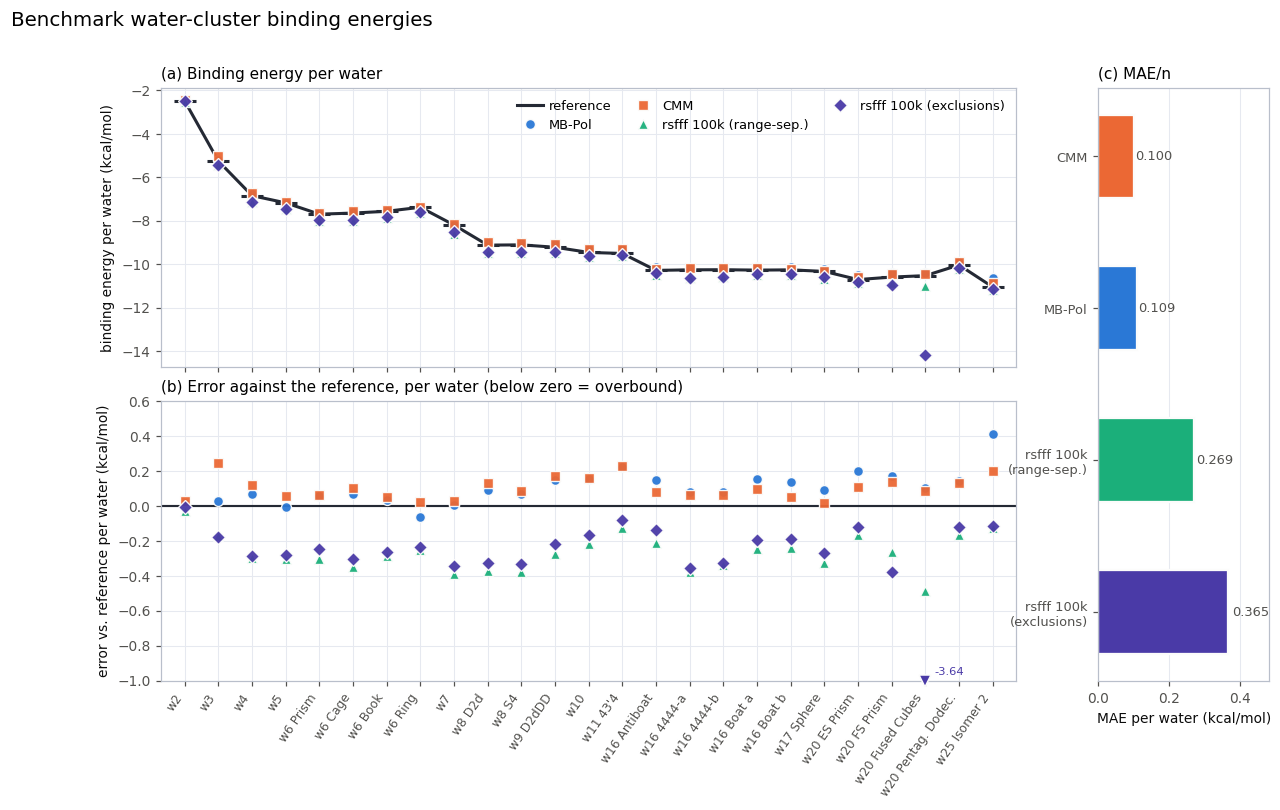

In [4]:
def energy_figure(path=None):
    """(a) the absolute curve for context, (b) the residual, (c) the aggregate.

    Panel (a) alone cannot show a 0.1 kcal/mol/water difference on a scale that runs from -2.5
    to -12; panel (b) alone loses the fact that the spread *between* isomers at fixed n is
    itself smaller than most of the errors. Both, sharing an x axis, say it in one read.
    """
    fig = plt.figure(figsize=(13.0, 7.0))
    gs = fig.add_gridspec(2, 2, width_ratios=[5.0, 1.0], hspace=0.12, wspace=0.16)
    ax_abs = fig.add_subplot(gs[0, 0])
    ax_err = fig.add_subplot(gs[1, 0])
    ax_mae = fig.add_subplot(gs[:, 1])

    ax_abs.plot(x, reference / n_waters, color=REFERENCE_INK, lw=2.0, zorder=1,
                marker="_", ms=14, mew=2.0, label="reference")
    for key, name, color, marker in METHODS:
        ax_abs.plot(x, energy[key] / n_waters, ls="none", marker=marker, ms=6.5, mew=0.9,
                    color=color, mec=SURFACE, alpha=0.95, label=name, zorder=2)
    ax_abs.set_ylabel("binding energy per water (kcal/mol)")
    ax_abs.set_xticks(x)
    ax_abs.set_xticklabels([])
    ax_abs.set_xlim(-0.7, len(rows) - 0.3)
    ax_abs.legend(ncol=3, loc="upper right", fontsize=8.5, columnspacing=1.4, handletextpad=0.5)
    ax_abs.set_title("(a) Binding energy per water", loc="left", fontsize=10)

    ax_err.axhline(0.0, color=REFERENCE_INK, lw=1.4, zorder=1)
    lo, hi = ERR_YLIM
    for key, name, color, marker in METHODS:
        err = (energy[key] - reference) / n_waters
        inside = (err >= lo) & (err <= hi)
        ax_err.plot(x[inside], err[inside], ls="none", marker=marker, ms=6.5,
                    mew=0.9, color=color, mec=SURFACE, alpha=0.95, zorder=2)
        # Off-scale points are pinned to the axis edge as arrows with their value, so one
        # collapsed cluster cannot flatten the residual of the other 24 into a line.
        for xi, e in zip(x[~inside], err[~inside]):
            edge = lo if e < lo else hi
            ax_err.plot(xi, edge, ls="none", marker="v" if e < lo else "^", ms=8, color=color,
                        mec=SURFACE, zorder=3, clip_on=False)
            ax_err.annotate(f"{e:+.2f}", (xi, edge), xytext=(6, 4 if e < lo else -10),
                            textcoords="offset points", fontsize=7.5, color=color)
    ax_err.set_ylim(lo, hi)
    ax_err.set_ylabel("error vs. reference per water (kcal/mol)")
    ax_err.set_xticks(x)
    ax_err.set_xticklabels(labels, rotation=55, ha="right", fontsize=8)
    ax_err.set_xlim(-0.7, len(rows) - 0.3)
    ax_err.set_title("(b) Error against the reference, per water (below zero = overbound)",
                     loc="left", fontsize=10)

    summary_bars(ax_mae, mae_per_water, "(c) MAE/n", "MAE per water (kcal/mol)")

    fig.suptitle("Benchmark water-cluster binding energies", x=0.02, ha="left", fontsize=13)
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = energy_figure(FIGDIR / "benchmark_clusters_energy.png")

Both 100k models **overbind** every cluster past the dimer, as the earlier rsfff checkpoints
did -- panel (b) is a band below zero, not a scatter around it. The dimer itself is right
(-0.03 and -0.005 kcal/mol per water).

The exclusion model's headline MAE/n (0.365, against 0.269 for the range-separated one) is
**one cluster**: `w20 Fused Cubes` relaxes 65 kcal/mol below its reference-geometry energy into
a rearranged structure (RMSD 0.51 A, 24 hydrogen bonds instead of 36) at -3.64 kcal/mol per
water. All four exclusion-committee members put that structure 65-105 kcal/mol below the
reference minimum, and the range-separated model puts it 16 kcal/mol *above* -- so this is a
systematic hole in the exclusion fit, not member noise, and not something the committee spread
would flag. It is where active learning on larger clusters has to look first.

Without it the exclusion model is the better of the two: MAE/n 0.229 against 0.259, and -- the
behaviour worth having -- a size-flat offset. Mean signed error per water is -0.26 at n <= 8
and -0.22 at n >= 16 (Fused Cubes excluded), against -0.29 and -0.25 for the range-separated
model. CMM is flat in n too (+0.08 to +0.09); MB-Pol drifts (+0.03 to +0.16).

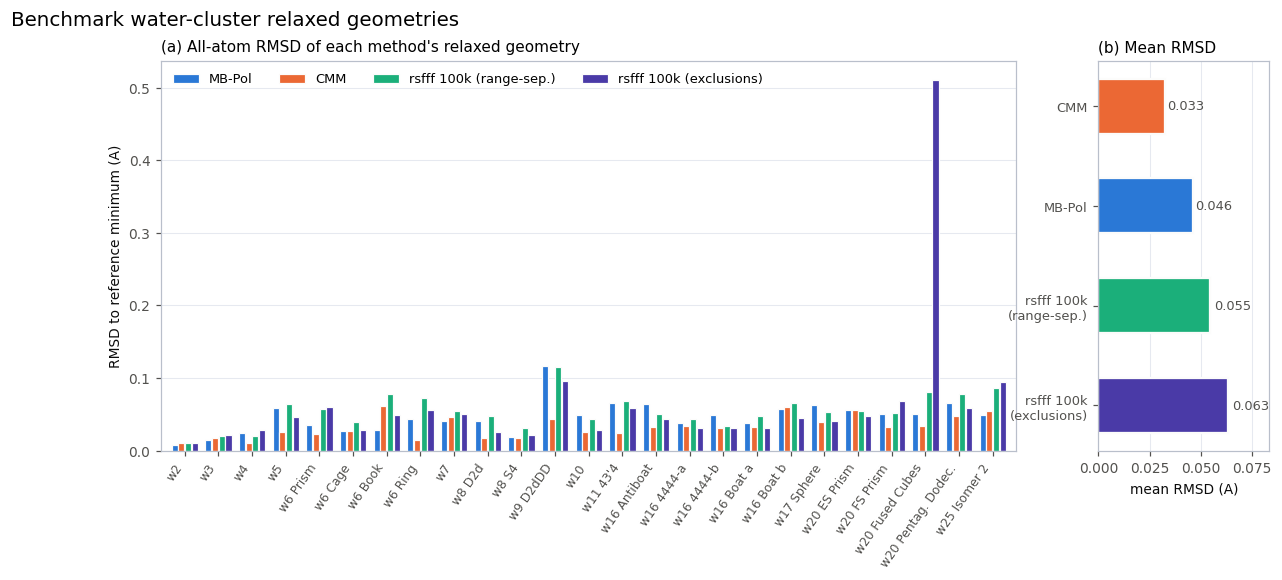

In [5]:
def rmsd_figure(path=None):
    """Grouped bars, linear scale on purpose.

    `w25 Isomer 2` sets the top of the axis and squashes everything else, and that is the
    honest picture -- it is the one cluster whose relaxed geometry genuinely moved, and a log
    axis would flatter it.
    """
    fig = plt.figure(figsize=(13.0, 4.6))
    gs = fig.add_gridspec(1, 2, width_ratios=[5.0, 1.0], wspace=0.16)
    ax = fig.add_subplot(gs[0, 0])
    ax_mean = fig.add_subplot(gs[0, 1])

    width = 0.2
    for i, (key, name, color, _marker) in enumerate(METHODS):
        offset = (i - (len(METHODS) - 1) / 2) * width
        ax.bar(x + offset, rmsd[key], width=width * 0.9, color=color,
               edgecolor=SURFACE, linewidth=0.8, label=name)
    ax.set_ylabel("RMSD to reference minimum (A)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=8)
    ax.set_xlim(-0.7, len(rows) - 0.3)
    ax.grid(axis="x", visible=False)
    ax.legend(ncol=4, loc="upper left", fontsize=8.5)
    ax.set_title("(a) All-atom RMSD of each method's relaxed geometry", loc="left", fontsize=10)

    summary_bars(ax_mean, mean_rmsd, "(b) Mean RMSD", "mean RMSD (A)")

    fig.suptitle("Benchmark water-cluster relaxed geometries", x=0.02, ha="left", fontsize=13)
    if path:
        fig.savefig(path, bbox_inches="tight")
    return fig


fig = rmsd_figure(FIGDIR / "benchmark_clusters_rmsd.png")

Geometries tell the same story. Mean all-atom RMSD is 0.055 A for the range-separated model and
0.063 A for the exclusion model, and the whole of that gap is `w20 Fused Cubes` (0.511 A): the
other 24 clusters average 0.045 A with exclusions against 0.054 A range-separated, next to
0.046 A for MB-Pol and 0.033 A for CMM. Everywhere else the hydrogen-bond topology survives
relaxation.

The shared hard cases are still shared. `w9 D2dDD` is among the worst for every method -- q-AQUA
(0.089), MB-Pol (0.116) and both 100k models (0.115 and 0.096) -- which says that minimum is flat
rather than that any one model is wrong about it. `w25 Isomer 2`, the largest cluster and the
furthest outside the training data, is no longer an outlier: 0.086 and 0.094 A, where the older
`film` / `film_large` checkpoints moved 0.320 and 0.202 A.

In [6]:
# The per-cluster numbers behind both figures, for reading off a specific isomer.
SHORT = {"film_100k": "100k range-sep", "film_100k_excl": "100k excl"}
header = f"{'cluster':<18}{'reference':>10}" + "".join(
    f"{SHORT.get(key, name):>15}" for key, name, *_ in METHODS)
print(header)
print("-" * len(header))
for i, label in enumerate(labels):
    line = f"{label:<18}{reference[i]:>10.2f}"
    for key, *_rest in METHODS:
        line += f"{energy[key][i]:>9.2f}{(energy[key][i] - reference[i]) / n_waters[i]:>+6.2f}"
    print(line)
print("\nenergies in kcal/mol; the small number beside each is that method's error per water")

cluster            reference         MB-Pol            CMM 100k range-sep      100k excl
----------------------------------------------------------------------------------------
w2                     -4.99    -4.96 +0.02    -4.93 +0.03    -5.05 -0.03    -5.00 -0.00
w3                    -15.77   -15.69 +0.03   -15.03 +0.25   -16.28 -0.17   -16.30 -0.18
w4                    -27.39   -27.12 +0.07   -26.91 +0.12   -28.59 -0.30   -28.54 -0.29
w5                    -35.90   -35.94 -0.01   -35.63 +0.05   -37.41 -0.30   -37.30 -0.28
w6 Prism              -46.20   -45.87 +0.06   -45.83 +0.06   -48.01 -0.30   -47.69 -0.25
w6 Cage               -45.90   -45.51 +0.07   -45.29 +0.10   -48.01 -0.35   -47.73 -0.30
w6 Book               -45.40   -45.19 +0.04   -45.10 +0.05   -47.13 -0.29   -46.99 -0.27
w6 Ring               -44.30   -44.70 -0.07   -44.18 +0.02   -45.80 -0.25   -45.71 -0.24
w7                    -57.40   -57.37 +0.00   -57.20 +0.03   -60.13 -0.39   -59.80 -0.34
w8 D2d               